In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from keras.preprocessing import image
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import Adam

Importing required libraries

In [2]:
# Read the labels.csv file and checking shape and records
labels_all = pd.read_csv('labels.csv')
print(labels_all.shape)
labels_all.head()

(10222, 2)


,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


Loading the labels data into dataframe and viewing it . Here we analyze that labels contain 10222 rows and 2 columns

In [3]:
# Visualize the number of each breed
breeds_all = labels_all['breed']
breeds_counts = breeds_all.value_counts()
breeds_counts.head()

breed
scottish_deerhound      126
maltese_dog             117
afghan_hound            116
entlebucher             115
bernese_mountain_dog    114
Name: count, dtype: int64

Finding out the count per class i.e. total data in each class using the value_counts() function

In [4]:
# Selecting first 3 breeds
CLASS_NAMES = ['scottish_deerhound', 'maltest_dog', 'bernese_mountain_dog']
labels = labels_all[(labels_all['breed'].isin(CLASS_NAMES))]
labels = labels.reset_index()
labels.head()

,index,id,breed
0,9,0042188c895a2f14ef64a918ed9c7b64,scottish_deerhound
1,79,01e787576c003930f96c966f9c3e1d44,scottish_deerhound
2,118,02d54f0dfb40038765e838459ae8c956,bernese_mountain_dog
3,161,03dc61595ad9dbf49e3998cf586ca8cb,scottish_deerhound
4,165,03e1d2ee5fd90aef036c90a9e7f81177,bernese_mountain_dog


In [5]:
# Creating numpy matrix with zeros
X_data = np.zeros ((len(labels), 224, 224, 3), dtype='float32')
# One hot encoding
Y_data = label_binarize(labels[ 'breed'], classes = CLASS_NAMES)

# Reading and converting image to numpy array and normalizing dataset
for i in tqdm(range(len(labels))):
    img = image. load_img( 'train/%s.jpg' % labels['id'][i], target_size=(224, 224))
    img = image. img_to_array(img)
    x = np.expand_dims(img.copy(), axis=0)
    X_data [i] = x / 255.0
# Printing train image and one hot encode shape & size
print('\nTrain Images shape: ',X_data.shape,' size: {:,}'. format(X_data.size))
print('One-hot encoded output shape: ',Y_data.shape,' size: {:,}'.format(Y_data.size))

100%|██████████| 240/240 [00:00<00:00, 995.27it/s] 


Train Images shape:  (240, 224, 224, 3)  size: 36,126,720
One-hot encoded output shape:  (240, 3)  size: 720


In [6]:
# Building the Model
model = Sequential()

model.add(Conv2D(filters=64, kernel_size = (5,5), activation='relu', input_shape=(224,224,3)))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=32, kernel_size = (3,3), activation='relu', kernel_regularizer='l2'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=16, kernel_size = (7,7), activation='relu', kernel_regularizer='l2'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=8, kernel_size = (5,5), activation='relu', kernel_regularizer='l2'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_regularizer='l2'))
model.add(Dense(64, activation='relu', kernel_regularizer='l2'))
model.add(Dense(len(CLASS_NAMES), activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer=Adam(0.0001),  metrics=['accuracy'])

model.summary()

/Users/aaravgoyal/Library/Python/3.12/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 108, 108, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 16)     │        25,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 8)      │         3,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,619 (635.23 KB)

 Trainable params: 162,619 (635.23 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Splitting the data into train and testing set
X_train_and_val, X_test, Y_train_and_val, Y_test = train_test_split(X_data, Y_data, test_size=0.1)
# Splitting data into train and validation set
X_train, X_val, Y_train, Y_val = train_test_split(X_train_and_val, Y_train_and_val, test_size=0.2)

In [8]:
# Training the model
history = model.fit(X_train, Y_train, batch_size=128, epochs=100, validation_data=(X_val, Y_val))

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 917ms/step - accuracy: 0.5291 - loss: 4.9151 - val_accuracy: 0.5682 - val_loss: 4.8764
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 862ms/step - accuracy: 0.5581 - loss: 4.8704 - val_accuracy: 0.6364 - val_loss: 4.8254
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 808ms/step - accuracy: 0.6221 - loss: 4.8248 - val_accuracy: 0.7727 - val_loss: 4.7656
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 788ms/step - accuracy: 0.6163 - loss: 4.7711 - val_accuracy: 0.7045 - val_loss: 4.6955
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 775ms/step - accuracy: 0.5930 - loss: 4.7080 - val_accuracy: 0.7500 - val_loss: 4.6168
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 772ms/step - accuracy: 0.5756 - loss: 4.6385 - val_accuracy: 0.7045 - val_loss: 4.5339
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 793ms/step - accuracy: 0.5523 - loss: 4.5672 - val_accuracy: 0.7500 - val_loss: 4.4549
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 835ms/step - accuracy: 0.5756 - loss: 4.4958 - val_accuracy: 0.7955 - v

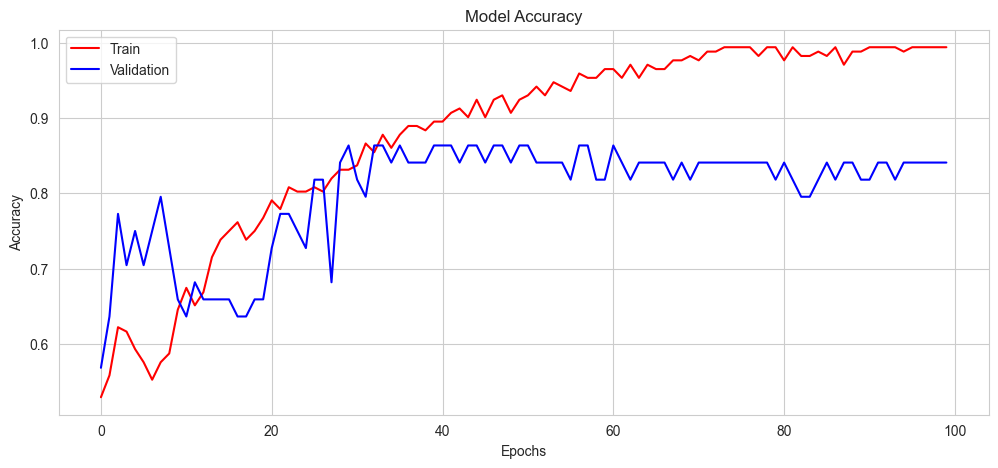

In [11]:
# Plot the training history
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'], color = 'red')
plt.plot(history.history['val_accuracy'], color = 'blue')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train', 'Validation'])
plt.show()